In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from google.colab import drive
import numpy as np

!numount /content/drive

drive.mount('/content/drive')

DRIVE_BASE_PATH = '/content/drive/MyDrive/Python/Dataset2'
ZIP_PATH = os.path.join(DRIVE_BASE_PATH, 'Dataset2.zip')
LOCAL_DATA_DIR = '/content/dataset'
CHECKPOINT_DIR = os.path.join(DRIVE_BASE_PATH, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'efficientnet_v2s_checkpoint.pth')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

/bin/bash: line 1: numount: command not found
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Đang sử dụng thiết bị: cuda


In [ ]:
import zipfile
import shutil

if os.path.exists(LOCAL_DATA_DIR):
    shutil.rmtree(LOCAL_DATA_DIR)
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if os.path.exists(ZIP_PATH):
    print(f"Bắt đầu giải nén {ZIP_PATH} vào {LOCAL_DATA_DIR}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_DATA_DIR)
    print("Giải nén dữ liệu hoàn tất!")
else:
    print(f"Cảnh báo: Không tìm thấy file zip tại {ZIP_PATH}. Vui lòng tải dữ liệu lên Drive đúng đường dẫn!")

Bắt đầu giải nén /content/drive/MyDrive/Python/Dataset2/Dataset2.zip vào /content/dataset...
Giải nén dữ liệu hoàn tất!


In [ ]:
import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter

subdirs = [d for d in os.listdir(LOCAL_DATA_DIR) if os.path.isdir(os.path.join(LOCAL_DATA_DIR, d))]
if len(subdirs) == 1 and subdirs[0] in ['cv_raw', 'cv_cleaned', 'dataset']:
    dataset_root = os.path.join(LOCAL_DATA_DIR, subdirs[0])
    subdirs = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]
else:
    dataset_root = LOCAL_DATA_DIR

classes = sorted(subdirs)
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}
print(f"Các lớp phát hiện được từ dữ liệu: {class_to_idx}")

image_paths = []
labels = []

valid_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
for cls_name in classes:
    cls_dir = os.path.join(dataset_root, cls_name)
    cls_idx = class_to_idx[cls_name]
    for ext in valid_extensions:
        files = glob.glob(os.path.join(cls_dir, ext))
        for f in files:
            image_paths.append(f)
            labels.append(cls_idx)

print(f"Tổng số ảnh thu thập được: {len(image_paths)}")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, stratify=labels, random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, stratify=temp_labels, random_state=42
)

print(f"Tập Train: {len(train_paths)} ảnh")
print(f"Tập Val: {len(val_paths)} ảnh")
print(f"Tập Test: {len(test_paths)} ảnh")

train_counts = Counter(train_labels)
val_counts = Counter(val_labels)
test_counts = Counter(test_labels)

print("CHI TIẾT SỐ LƯỢNG ẢNH MỖI LỚP TRONG TỪNG TẬP:")
for idx in sorted(idx_to_class.keys()):
    class_name = idx_to_class[idx]
    print(f" * Lớp '{class_name}' (ID: {idx}):")
    print(f"   - Train : {train_counts.get(idx, 0)} ảnh")
    print(f"   - Val   : {val_counts.get(idx, 0)} ảnh")
    print(f"   - Test  : {test_counts.get(idx, 0)} ảnh")

def compute_alpha_weights(train_labels, num_classes):
  counts = Counter(train_labels)
  total_samples = len(train_labels)
  class_counts = np.array([counts.get(i,1) for i in range(num_classes)], dtype=np.float32)
  class_weights = total_samples / (num_classes * class_counts)
  return class_weights

alpha_weights = compute_alpha_weights(train_labels, len(classes))
print(f"Alpha weights: {alpha_weights}")

class CustomImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

Các lớp phát hiện được từ dữ liệu: {'cracked': 0, 'display_defect': 1, 'good': 2, 'scratch': 3}
Tổng số ảnh thu thập được: 1919
Tập Train: 1343 ảnh
Tập Val: 288 ảnh
Tập Test: 288 ảnh
CHI TIẾT SỐ LƯỢNG ẢNH MỖI LỚP TRONG TỪNG TẬP:
 * Lớp 'cracked' (ID: 0):
   - Train : 429 ảnh
   - Val   : 92 ảnh
   - Test  : 92 ảnh
 * Lớp 'display_defect' (ID: 1):
   - Train : 274 ảnh
   - Val   : 59 ảnh
   - Test  : 59 ảnh
 * Lớp 'good' (ID: 2):
   - Train : 357 ảnh
   - Val   : 76 ảnh
   - Test  : 77 ảnh
 * Lớp 'scratch' (ID: 3):
   - Train : 283 ảnh
   - Val   : 61 ảnh
   - Test  : 60 ảnh
Alpha weights: [0.782634  1.2253649 0.9404762 1.1863958]


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CustomImageDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = CustomImageDataset(val_paths, val_labels, transform=val_test_transforms)
test_dataset = CustomImageDataset(test_paths, test_labels, transform=val_test_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
weights = models.EfficientNet_V2_S_Weights.DEFAULT
model = models.efficientnet_v2_s(weights=weights)

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(classes))

model = model.to(device)
print(f"Mô hình EfficientNetV2-S đã sẵn sàng với {len(classes)} ngõ ra!")

Mô hình EfficientNetV2-S đã sẵn sàng với 4 ngõ ra!


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha

        if alpha is not None:
            if isinstance(alpha, (float, int)):
                self.alpha = torch.Tensor([alpha, 1 - alpha])
            elif isinstance(alpha, (list, tuple, np.ndarray)):
                self.alpha = torch.tensor(alpha, dtype=torch.float32)
            elif isinstance(alpha, torch.Tensor):
                self.alpha = alpha.float()

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        if self.alpha is not None:
            self.alpha = self.alpha.to(inputs.device)
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        else:
            focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
import torch.optim as optim

criterion = FocalLoss(alpha_weights ,gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

start_epoch = 0
best_val_acc = 0.0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

if os.path.exists(CHECKPOINT_PATH):
    print(f"Tìm thấy checkpoint! Đang tiến hành nạp từ {CHECKPOINT_PATH}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    train_accs = checkpoint.get('train_accs', [])
    val_accs = checkpoint.get('val_accs', [])
    print(f"Khôi phục thành công! Tiếp tục huấn luyện từ epoch {start_epoch + 1} (Val Acc tốt nhất hiện tại: {best_val_acc:.4f})")
else:
    print("Không tìm thấy checkpoint trên Drive. Bắt đầu huấn luyện mới từ đầu.")

Tìm thấy checkpoint! Đang tiến hành nạp từ /content/drive/MyDrive/Python/Dataset2/checkpoints/efficientnet_v2s_checkpoint.pth...
Khôi phục thành công! Tiếp tục huấn luyện từ epoch 31 (Val Acc tốt nhất hiện tại: 0.9792)


In [ ]:
import time

num_epochs = 30
print("Bắt đầu huấn luyện...")

for epoch in range(start_epoch, num_epochs):
    epoch_start = time.time()

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    scheduler.step(epoch_val_loss)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    epoch_duration = time.time() - epoch_start
    print(f"Epoch {epoch+1}/{num_epochs} [{epoch_duration:.0f}s] - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    checkpoint_data = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_acc': max(best_val_acc, epoch_val_acc),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }
    torch.save(checkpoint_data, CHECKPOINT_PATH)
    print(f"Checkpoint phục hồi đã được lưu tại {CHECKPOINT_PATH}")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_path = os.path.join(CHECKPOINT_DIR, 'efficientnet_v2s_best.pth')
        torch.save(model.state_dict(), best_model_path)
        print(f"Phát hiện mô hình tốt nhất mới! Val Acc: {best_val_acc:.4f}. Đã lưu trọng số.")

print("Huấn luyện hoàn tất!")

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(epochs_range, val_losses, label='Val Loss', color='red', marker='x')
plt.title('Đồ thị Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label='Train Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_accs, label='Val Accuracy', color='red', marker='x')
plt.title('Đồ thị Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

best_model_path = os.path.join(CHECKPOINT_DIR, 'efficientnet_v2s_best.pth')
if os.path.exists(best_model_path):
    print(f"Đang nạp trọng số tốt nhất từ {best_model_path}...")
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("Nạp trọng số thành công!")

model.eval()
all_preds = []
all_targets = []
test_images_sample = []
test_labels_sample = []
test_preds_sample = []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.numpy())

        if len(test_images_sample) < 5:
            test_images_sample.append(images[0])
            test_labels_sample.append(labels[0].item())
            test_preds_sample.append(preds[0].item())

print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):")
report = classification_report(all_targets, all_preds, target_names=classes)
print(report)

f1_scores = f1_score(all_targets, all_preds, average=None)
plt.figure(figsize=(10, 5))
plt.bar(classes, f1_scores, color='skyblue', edgecolor='black')
plt.title('Đồ thị F1-Score cho từng lớp')
plt.xlabel('Lớp')
plt.ylabel('F1-Score')
plt.ylim(0, 1.05)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix)')
plt.xlabel('Lớp dự đoán (Predicted)')
plt.ylabel('Lớp thực tế (Actual)')
plt.show()

def imshow(img, title):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    npimg = img.numpy().transpose((1, 2, 0))
    npimg = std * npimg + mean
    npimg = np.clip(npimg, 0, 1)

    plt.imshow(npimg)
    plt.title(title, fontsize=12, color='green' if 'Đúng' in title else 'red')
    plt.axis('off')

plt.figure(figsize=(20, 4))
for idx in range(min(len(test_images_sample), 5)):
    plt.subplot(1, 5, idx + 1)
    actual_class = classes[test_labels_sample[idx]]
    pred_class = classes[test_preds_sample[idx]]
    is_correct = "Đúng" if test_labels_sample[idx] == test_preds_sample[idx] else "Sai"

    title = f"Thực tế: {actual_class}\nDự đoán: {pred_class}\n({is_correct})"
    imshow(test_images_sample[idx], title)

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def predict_image_url(image_url, model_path, classes):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    weights = models.EfficientNet_V2_S_Weights.DEFAULT
    model = models.efficientnet_v2_s(weights=weights)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, len(classes))

    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Đã nạp trọng số mô hình tốt nhất từ {model_path}")
    else:
        raise FileNotFoundError(f"Không tìm thấy file trọng số tại {model_path}")

    model = model.to(device)
    model.eval()

    print(f"Đang tải ảnh từ URL: {image_url}...")
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(image_url, headers=headers, verify=False)
    img = Image.open(BytesIO(response.content)).convert('RGB')

    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probabilities, 1)

    pred_class = classes[pred_idx.item()]
    confidence_val = confidence.item() * 100

    print(f"\nKết quả dự đoán:")
    print(f"Lớp dự đoán: {pred_class}")
    print(f"Độ tin cậy (Confidence): {confidence_val:.2f}%")

    plt.imshow(img)
    plt.title(f"Dự đoán: {pred_class} ({confidence_val:.2f}%)")
    plt.axis('off')
    plt.show()

sample_url = "blob:https://www.facebook.com/1b90540c-c520-493d-bc27-dbf8c1e9daae"
best_model_path = os.path.join(CHECKPOINT_DIR, 'efficientnet_v2s_best.pth')

try:
    predict_image_url(sample_url, best_model_path, classes)
except Exception as e:
    print(f"Lỗi khi thực hiện dự đoán: {e}")

Vui lòng chọn 1 file ảnh từ máy tính của bạn:


Saving 1b90540c-c520-493d-bc27-dbf8c1e9daae.jpg to 1b90540c-c520-493d-bc27-dbf8c1e9daae (1).jpg
Đã nạp trọng số mô hình tốt nhất từ /content/drive/MyDrive/Python/Dataset2/checkpoints/efficientnet_v2s_best.pth

Kết quả dự đoán:
Lớp dự đoán: display_defect
Độ tin cậy (Confidence): 95.47%


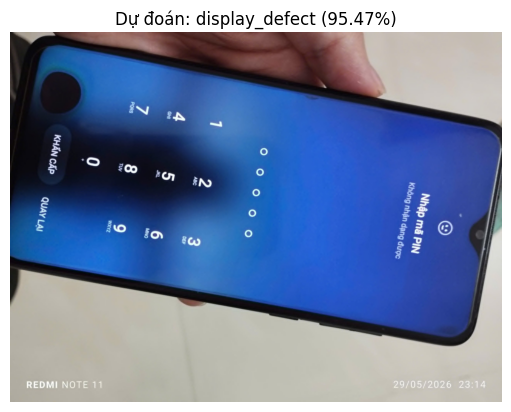

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files  # Thư viện hỗ trợ upload file trên Colab

def predict_image_local(image_path, model_path, classes):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. Khởi tạo cấu trúc mô hình
    weights = models.EfficientNet_V2_S_Weights.DEFAULT
    model = models.efficientnet_v2_s(weights=weights)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, len(classes))

    # 2. Nạp trọng số từ file .pth
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Đã nạp trọng số mô hình tốt nhất từ {model_path}")
    else:
        raise FileNotFoundError(f"Không tìm thấy file trọng số tại {model_path}")

    model = model.to(device)
    model.eval()

    # 3. Đọc và tiền xử lý ảnh
    img = Image.open(image_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    # 4. Dự đoán
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probabilities, 1)

    pred_class = classes[pred_idx.item()]
    confidence_val = confidence.item() * 100

    print(f"\nKết quả dự đoán:")
    print(f"Lớp dự đoán: {pred_class}")
    print(f"Độ tin cậy (Confidence): {confidence_val:.2f}%")

    # 5. Hiển thị kết quả bằng matplotlib
    plt.imshow(img)
    plt.title(f"Dự đoán: {pred_class} ({confidence_val:.2f}%)")
    plt.axis('off')
    plt.show()

# ==================== TIẾN HÀNH UPLOAD VÀ CHẠY ĐOÁN ====================

best_model_path = os.path.join(CHECKPOINT_DIR, 'efficientnet_v2s_best.pth')

try:
    print("Vui lòng chọn 1 file ảnh từ máy tính của bạn:")
    uploaded = files.upload()  # Xuất hiện nút bấm chọn file

    if uploaded:
        # Lấy tên file ảnh vừa được tải lên thành công
        local_image_path = list(uploaded.keys())[0]

        # Gọi hàm dự đoán (Sử dụng biến 'classes' kế thừa từ các cell trước)
        predict_image_local(local_image_path, best_model_path, classes)

        # Tùy chọn: Xóa file ảnh tạm này sau khi dự đoán xong để tránh rác bộ nhớ Colab
        os.remove(local_image_path)
    else:
        print("Bạn đã hủy chọn file.")

except Exception as e:
    print(f"Lỗi khi thực hiện dự đoán: {e}")

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
!pip install onnx onnxscript

def export_to_onnx(pytorch_model_path, onnx_model_output_path, num_classes=4):
    weights = models.EfficientNet_V2_S_Weights.DEFAULT
    model = models.efficientnet_v2_s(weights=weights)
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, num_classes)

    state_dict = torch.load(pytorch_model_path, map_location='cpu')
    if 'model_state_dict' in state_dict:
        model.load_state_dict(state_dict['model_state_dict'])
    else:
        model.load_state_dict(state_dict)

    model.eval()

    dummy_input = torch.randn(1, 3, 224, 224, requires_grad=False)

    print(f"Đang xuất mô hình từ {pytorch_model_path} sang {onnx_model_output_path}...")
    torch.onnx.export(
        model,
        dummy_input,
        onnx_model_output_path,
        export_params=True,
        opset_version=15,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
    )
    print("Xuất mô hình sang ONNX thành công!")

best_model_path = os.path.join(CHECKPOINT_DIR, 'efficientnet_v2s_best.pth')
onnx_output_path = os.path.join(DRIVE_BASE_PATH, 'cv_model.onnx')

export_to_onnx(best_model_path, onnx_output_path, num_classes=len(classes))